In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('CKD_NHANES_2021_2023 (1).csv')

In [4]:
data.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [5]:
data.shape

(11933, 29)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  object 
 3   ethnicity                 11933 non-null  object 
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosph

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
participant_id,11933.0,136344.000000,3444.904716,1.303780e+05,133361.0000,136344.00,139327.00,142310.00
age,11933.0,38.317858,25.601990,5.397605e-79,13.0000,37.00,62.00,80.00
education_level,7794.0,3.804978,1.153750,1.000000e+00,3.0000,4.00,5.00,9.00
poverty_income_ratio,9892.0,2.708174,1.670119,5.397605e-79,1.1800,2.50,4.50,5.00
bmi,8471.0,27.246665,8.137781,1.110000e+01,21.6000,26.40,31.70,74.80
weight_kg,8754.0,70.549037,30.389021,2.700000e+00,54.2000,71.70,89.10,248.20
height_cm,8499.0,159.664549,19.864943,7.910000e+01,154.4000,163.60,172.10,200.70
bp_systolic,7517.0,119.288546,18.561052,6.100000e+01,106.0000,117.00,130.00,232.00
bp_diastolic,7517.0,72.748038,11.895572,3.300000e+01,64.0000,72.00,80.00,142.00
serum_creatinine,6326.0,0.872828,0.385498,3.300000e-01,0.7000,0.83,0.98,15.17


In [8]:
data.drop(columns=['participant_id','age','ethnicity','gender','education_level','bmi' , 'poverty_income_ratio',
   'weight_kg',
    'height_cm',
    'bp_systolic',
   'bp_diastolic', 'phosphorus', 'calcium', 'bicarbonate', 'uric_acid', 'diabetes_diagnosed', 'insulin_use', 'ever_smoked', 'current_smoker','diabetes_pills'],axis=1,inplace=True)

In [9]:
data.drop('ckd_present',axis=1,inplace=True)

In [10]:
data.head()

,serum_creatinine,blood_urea_nitrogen,albumin_serum,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr,ckd_stage
0,0.80,11.0,4.3,136.0,23.12,17.00,112.61,No CKD
1,0.79,24.0,3.9,64.0,4.25,6.64,97.98,No CKD
2,0.64,10.0,3.7,157.0,12.43,7.92,111.69,No CKD
3,NaN,NaN,NaN,208.0,16.12,7.75,NaN,Unknown
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown


In [11]:
data.isna().sum()

,0
serum_creatinine,5607
blood_urea_nitrogen,5607
albumin_serum,5567
urine_creatinine,3779
urine_albumin,3780
albumin_creatinine_ratio,3780
egfr,5607
ckd_stage,0


In [12]:
data.duplicated().sum()

np.int64(3697)

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
original_len = len(data)

print(f"Original shape: {data.shape}")
data.dropna(inplace=True)
print(f"After dropping: {data.shape}")
print(f"Data lost: {(1 - len(data)/original_len) * 100:.1f}%")

Original shape: (8236, 8)
After dropping: (6199, 8)
Data lost: 24.7%


In [16]:
data.isna().sum()

,0
serum_creatinine,0
blood_urea_nitrogen,0
albumin_serum,0
urine_creatinine,0
urine_albumin,0
albumin_creatinine_ratio,0
egfr,0
ckd_stage,0


In [17]:
data['ckd_stage'].unique()

array(['No CKD', 'Stage 2 (Mildly Decreased)', 'Stage 1 (Kidney Damage)',
       'Stage 4 (Severely Decreased)', 'Stage 3a (Mild-Moderate)',
       'Stage 3b (Moderate-Severe)', 'Stage 5 (Kidney Failure)'],
      dtype=object)

In [18]:
data['class'] = data['ckd_stage'].map({'No CKD': 0, 'Stage 1 (Kidney Damage)' : 1, 'Stage 2 (Mildly Decreased)' : 2,
       'Stage 3a (Mild-Moderate)' : 3, 'Stage 3b (Moderate-Severe)' : 4,
       'Stage 4 (Severely Decreased)' : 5, 'Stage 5 (Kidney Failure)' : 6})

In [19]:
data.drop('ckd_stage',axis=1,inplace=True)

In [20]:
data.head()

,serum_creatinine,blood_urea_nitrogen,albumin_serum,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr,class
0,0.80,11.0,4.3,136.0,23.12,17.00,112.61,0
1,0.79,24.0,3.9,64.0,4.25,6.64,97.98,0
2,0.64,10.0,3.7,157.0,12.43,7.92,111.69,0
8,0.82,17.0,4.3,113.0,4.60,4.07,118.21,0
9,0.76,15.0,3.7,23.0,5.93,25.78,85.30,2


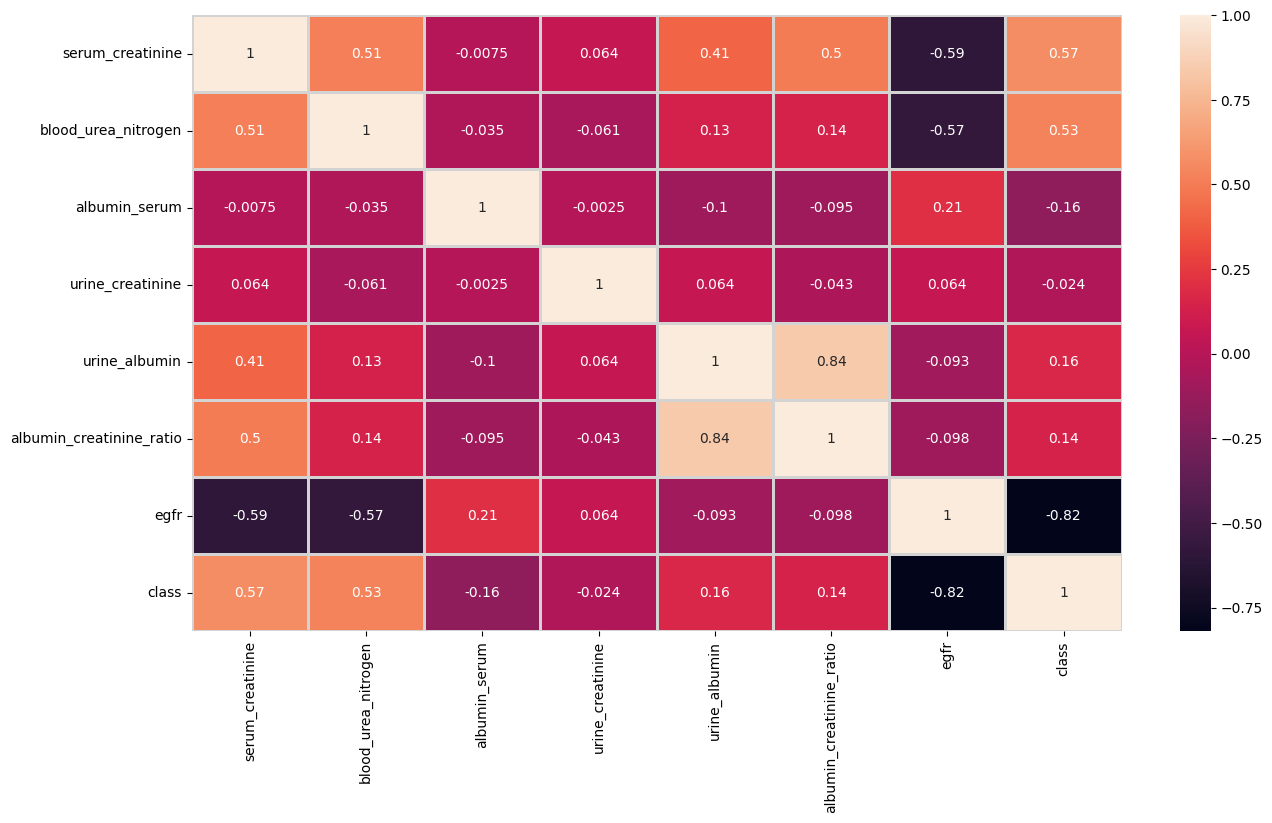

In [21]:
plt.figure(figsize = (15, 8))

sns.heatmap(data.corr(), annot = True, linewidths = 2, linecolor = 'lightgrey')
plt.show()

In [22]:
numeric_cols = ['serum_creatinine',
'blood_urea_nitrogen',
'albumin_serum',
'urine_creatinine',
'urine_albumin',
'albumin_creatinine_ratio','egfr']

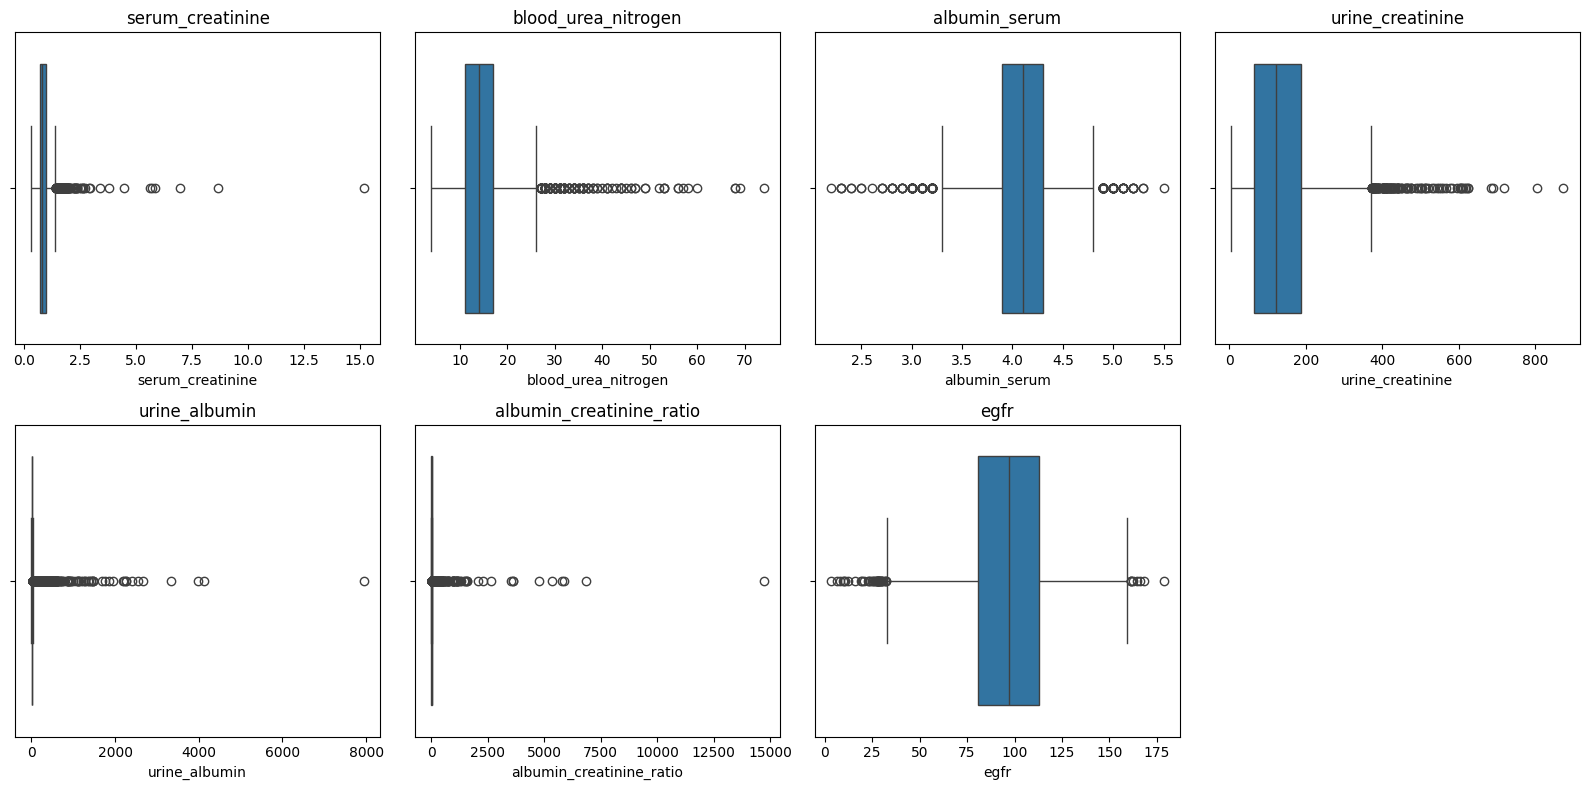

In [23]:
n_cols = 4   # number of plots per row
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

axes = axes.flatten()  # Flatten in case of multiple rows

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=data[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
X =  data.drop('class',axis=1)
y = data['class']

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
X_scaled_train,X_scaled_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

xgb = XGBClassifier()
xgb.fit(X_scaled_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('xgb', XGBClassifier()),
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_scaled_train, y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier()),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())


  Random Forest
Accuracy: 0.9976
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       716
           1       1.00      1.00      1.00        84
           2       1.00      0.99      1.00       358
           3       0.97      1.00      0.98        63
           4       0.92      1.00      0.96        12
           5       1.00      0.83      0.91         6
           6       1.00      1.00      1.00         1

    accuracy                           1.00      1240
   macro avg       0.98      0.98      0.98      1240
weighted avg       1.00      1.00      1.00      1240



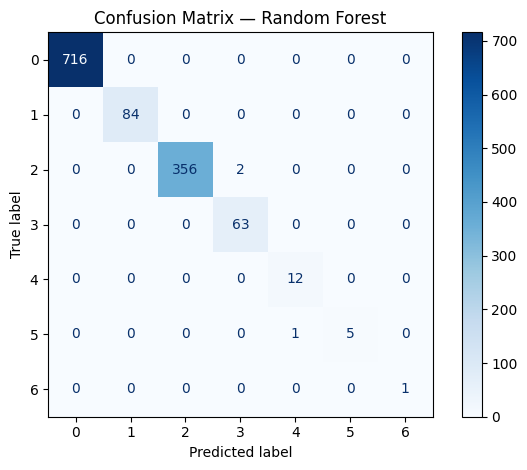


  Gradient Boosting
Accuracy: 0.9976
ROC-AUC Score: 0.9997

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       716
           1       1.00      0.99      0.99        84
           2       1.00      0.99      1.00       358
           3       0.97      1.00      0.98        63
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00         1

    accuracy                           1.00      1240
   macro avg       1.00      1.00      1.00      1240
weighted avg       1.00      1.00      1.00      1240



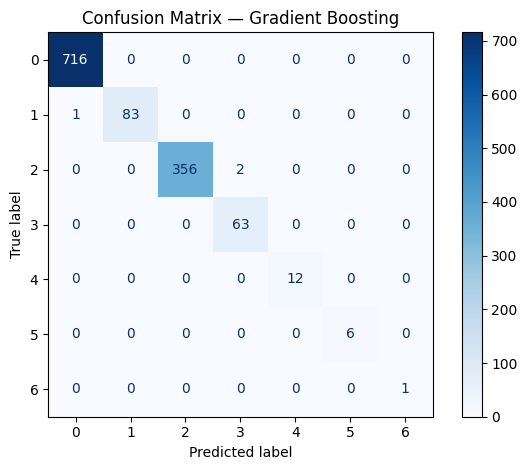


  AdaBoost
Accuracy: 0.8661
ROC-AUC Score: 0.9326

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       716
           1       0.00      0.00      0.00        84
           2       0.82      1.00      0.90       358
           3       0.00      0.00      0.00        63
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         1

    accuracy                           0.87      1240
   macro avg       0.24      0.29      0.26      1240
weighted avg       0.75      0.87      0.80      1240



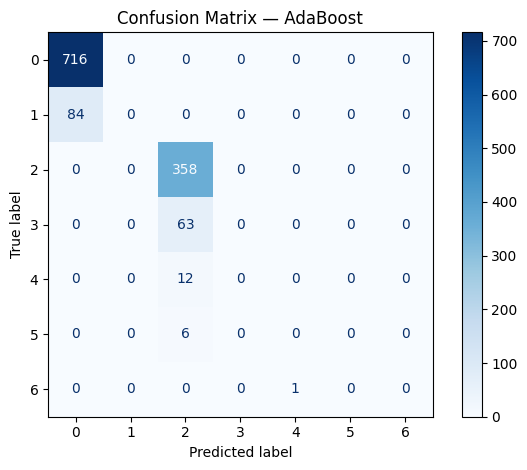


  XGBoost
Accuracy: 0.9968
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       716
           1       1.00      0.99      0.99        84
           2       0.99      1.00      1.00       358
           3       1.00      0.97      0.98        63
           4       0.92      1.00      0.96        12
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00         1

    accuracy                           1.00      1240
   macro avg       0.99      0.99      0.99      1240
weighted avg       1.00      1.00      1.00      1240



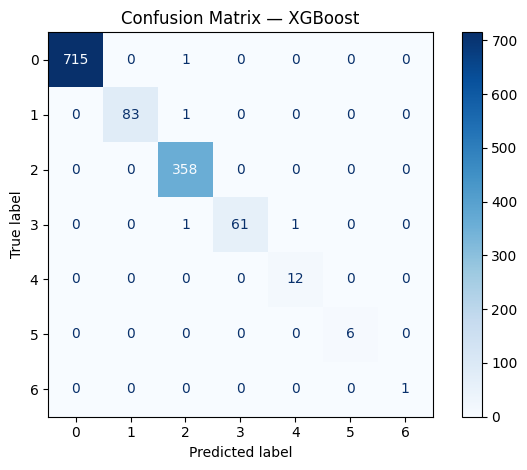


  Stacking
Accuracy: 0.9976
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       716
           1       1.00      0.99      0.99        84
           2       1.00      0.99      1.00       358
           3       0.97      1.00      0.98        63
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00         1

    accuracy                           1.00      1240
   macro avg       1.00      1.00      1.00      1240
weighted avg       1.00      1.00      1.00      1240



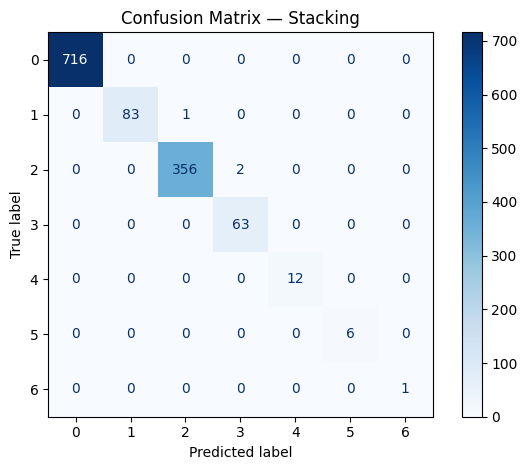


  FINAL MODEL COMPARISON
            Model  Accuracy  ROC-AUC
    Random Forest  0.997581 0.999999
         Stacking  0.997581 0.999998
          XGBoost  0.996774 0.999986
Gradient Boosting  0.997581 0.999741
         AdaBoost  0.866129 0.932631

  BEST MODEL: Random Forest
  Accuracy : 0.9976
  ROC-AUC  : 1.0000


In [32]:
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Base models
base_models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('AdaBoost', AdaBoostClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42))
]

# Stacking model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# All models including stacking
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Stacking': stacking_model
}

results = []  # To compare all models at the end

for name, model in models.items():
    model.fit(X_scaled_train, y_train)
    y_pred = model.predict(X_scaled_test)
    y_prob = model.predict_proba(X_scaled_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC-AUC
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    print(f"ROC-AUC Score: {auc:.4f}")

    # Store results
    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc})

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

# ── Final Comparison Table ──────────────────────────────
print("\n" + "="*50)
print("  FINAL MODEL COMPARISON")
print("="*50)
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

best_row = results_df.iloc[0]  # Already sorted by ROC-AUC descending
best_name = best_row['Model']
best_model = models[best_name]

print(f"\n{'='*50}")
print(f"  BEST MODEL: {best_name}")
print(f"  Accuracy : {best_row['Accuracy']:.4f}")
print(f"  ROC-AUC  : {best_row['ROC-AUC']:.4f}")
print(f"{'='*50}")

In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ── Save the best model (change to whichever performed best) ──
best_model = models['XGBoost']  # or 'Stacking', 'Random Forest', etc.
joblib.dump(best_model, 'ckd_model.pkl')
joblib.dump(scaler, 'scaler.pkl')  # save your scaler too
print("✅ Model and scaler saved!")

# ── Load them back ────────────────────────────────────────────
loaded_model = joblib.load('ckd_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
print("✅ Model and scaler loaded!")

# ── Feature names (must match your training columns) ──────────
feature_names = X.columns.tolist()
print(f"\nExpected features: {feature_names}")

# ── Fake Patient Data ─────────────────────────────────────────
# Normal healthy person — all values within normal clinical range
stage0_patient = {
    'serum_creatinine':          0.8,
    'blood_urea_nitrogen':       12.0,
    'albumin_serum':             4.5,
    'urine_creatinine':          110.0,
    'urine_albumin':             5.0,
    'albumin_creatinine_ratio':  6.0,
    'egfr':                      105.0,
}

# ── Stage 6 — Most Severe / Complete Kidney Failure ───────────
stage6_patient = {
    'serum_creatinine':          15.0,    # Extremely high
    'blood_urea_nitrogen':       95.0,    # Extremely high
    'albumin_serum':             1.8,     # Critically low
    'urine_creatinine':          5.0,     # Critically low
    'urine_albumin':             9000.0,  # Extremely high
    'albumin_creatinine_ratio':  12000.0, # Extremely high
    'egfr':                      2.0,     # Near zero
}
# ── Test Both ─────────────────────────────────────────────────
for label, patient in [("🟢 Stage 0 - Healthy", stage0_patient),
                        ("⚫ Stage 6 - Most Severe", stage6_patient)]:
    df = pd.DataFrame([patient], columns=feature_names)
    df_scaled = loaded_scaler.transform(df)

    prediction = loaded_model.predict(df_scaled)[0]
    probability = loaded_model.predict_proba(df_scaled)[0]

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Predicted CKD Stage : {prediction}")
    print(f"  Confidence per class:")
    for stage, prob in zip(loaded_model.classes_, probability):
        print(f"    Stage {stage}: {prob*100:.1f}%")

✅ Model and scaler saved!
✅ Model and scaler loaded!

Expected features: ['serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr']

  🟢 Stage 0 - Healthy
  Predicted CKD Stage : 0
  Confidence per class:
    Stage 0: 100.0%
    Stage 1: 0.0%
    Stage 2: 0.0%
    Stage 3: 0.0%
    Stage 4: 0.0%
    Stage 5: 0.0%
    Stage 6: 0.0%

  ⚫ Stage 6 - Most Severe
  Predicted CKD Stage : 6
  Confidence per class:
    Stage 0: 0.0%
    Stage 1: 0.2%
    Stage 2: 0.2%
    Stage 3: 0.3%
    Stage 4: 0.3%
    Stage 5: 6.3%
    Stage 6: 92.8%
